In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/raw/kiva_loans.csv')
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14,NaN,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6,"user_favorite, user_favorite",female,bullet,2014-01-01
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8,NaN,female,irregular,2014-01-01
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16,NaN,female,monthly,2014-01-01


In [3]:
# df.sample(n=200000, random_state=42)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  671205 non-null  int64  
 1   funded_amount       671205 non-null  float64
 2   loan_amount         671205 non-null  float64
 3   activity            671205 non-null  str    
 4   sector              671205 non-null  str    
 5   use                 666973 non-null  str    
 6   country_code        671197 non-null  str    
 7   country             671205 non-null  str    
 8   region              614405 non-null  str    
 9   currency            671205 non-null  str    
 10  partner_id          657698 non-null  float64
 11  posted_time         671205 non-null  str    
 12  disbursed_time      668809 non-null  str    
 13  funded_time         622874 non-null  str    
 14  term_in_months      671205 non-null  float64
 15  lender_count        671205 non-null  int64  


In [5]:
df.describe().round(3)

,id,funded_amount,loan_amount,partner_id,term_in_months,lender_count
count,671205.000,671205.000,671205.000,657698.000,671205.000,671205.000
mean,993248.594,785.995,842.397,178.200,13.739,20.591
std,196611.275,1130.399,1198.660,94.248,8.599,28.460
min,653047.000,0.000,25.000,9.000,1.000,0.000
25%,823072.000,250.000,275.000,126.000,8.000,7.000
50%,992780.000,450.000,500.000,145.000,13.000,13.000
75%,1163653.000,900.000,1000.000,204.000,14.000,24.000
max,1340339.000,100000.000,100000.000,536.000,158.000,2986.000


## Cek missing value

In [6]:
print(f'{'Fitur':<23} | {"Jumlah missing":<17} | {'Persentase'}')
for i in df.columns:
    # hitung missing value pada semua fitur
    missing_value = df[i].isnull().sum()
    presentase = (missing_value / len(df) * 100)

    if missing_value > 0:
        print(f'{i:<20}    | {missing_value:<15}  |  {presentase:.2f}%')

Fitur                   | Jumlah missing    | Persentase
use                     | 4232             |  0.63%
country_code            | 8                |  0.00%
region                  | 56800            |  8.46%
partner_id              | 13507            |  2.01%
disbursed_time          | 2396             |  0.36%
funded_time             | 48331            |  7.20%
tags                    | 171416           |  25.54%
borrower_genders        | 4221             |  0.63%


# Data Validation
#### Feature Engineering Tipis-Tipis

- Pada tahap ini mengonversi type data string khsusnya pda bagian `posted_time`, `disbursed_time` dan `funded_time` menjadi type data Datetime utk nantinya di jadikan sebagai analisis di EDA (Exploration Data Analysis)

In [7]:
# mengubah type data dari string menjadi datatime
df['posted_time'] = pd.to_datetime(df['posted_time'], utc=True)
df['disbursed_time'] = pd.to_datetime(df['disbursed_time'], utc=True)
df['funded_time'] = pd.to_datetime(df['funded_time'], utc=True)

# feature engineering
df['days_to_fund'] = (df['funded_time'] - df['posted_time']).dt.days 
df['fully_funded'] = (df['funded_amount'] >= df['loan_amount']).astype(int)
df['funding_gap'] = (df['loan_amount'] - df['funded_amount'])

# cek statistik lamanya pinjaman terpenuhi
df['days_to_fund'].describe().round(2)

count    622874.00
mean         14.15
std          14.41
min         -18.00
25%           5.00
50%           9.00
75%          22.00
max         420.00
Name: days_to_fund, dtype: float64

## ANALISIS FUNDING GAP & ANOMALI
- Dari FE yang sudah dibuat nilai dari fitur `days_to_fund` dan `funding_gap` ada yang bernilai negatif dan bakal jadi masalah kalau tidak di atasi
- `funding_gap` dari jumlah yang di ajukan masih ada kekurangan dana sebanyak 48.328 data dengan rumus (pinjaman - dana yang terkumpul)
---
- JUSTIFIKASI TARGET VARIABLE: `days_to_fund = funded_time - posted_time`
Bukan `disbursed_time - funded_time` karena:
  1. disbursed_time mencerminkan proses operasional Field Partner,
     bukan respons lender terhadap loan posting.
  2. Kiva menggunakan pre-disbursed model untuk sebagian loan
     dana sudah cair ke peminjam sebelum loan diposting,
     sehingga disbursed_time < posted_time secara valid.
  3. Target bisnis kita adalah mengukur daya tarik loan
     di mata lender, bukan kecepatan operasional internal Kiva.
---

- PENYEBAB `conflict`: Pinjaman terpenuhi 100% (funded_amount = loan_amount)
tapi sistem tidak mencatat kapan funded_time-nya.
Kemungkinan: bug logging di sistem Kiva pada periode tertentu.

  IMPLIKASI:
  Ketiga baris ini fully_funded = 1, tapi days_to_fund = NaN.
  Tidak bisa diikutkan dalam model regresi karena target missing.
  Akan di-exclude di Notebook 2 bersama anomali lainnya.

In [8]:
# cek anomali funding_gap
funded = (df['funding_gap'] == 0).sum()  
not_fully_dunded = (df['funding_gap'] > 0).sum()
overfunded = (df['funding_gap'] < 0).sum()

# anomali pada data days_to_fund
neg_days = df[df['days_to_fund'] < 0]

# anomali pada data fully_funded fully_funded=1 tapi funded_time = NaN
conflict = df[(df['funding_gap'] == 0) & (df['funded_time'].isna())]

print(f'Dana terpenuhi         : {funded}')
print(f'Dana yang masih kurang : {not_fully_dunded}')
print(f'Dana yang lebih        : {overfunded}\n')
print(f'Dana yang lebih        : {len(neg_days)}')
print(neg_days[['id','posted_time','funded_time','days_to_fund']].head().to_string())
print()
print(f"Jumlah : {len(conflict):,} baris")
print(conflict[['id','loan_amount','funded_amount','posted_time','funded_time']].to_string())

Dana terpenuhi         : 622875
Dana yang masih kurang : 48328
Dana yang lebih        : 2

Dana yang lebih        : 1
             id               posted_time               funded_time  days_to_fund
636606  1281091 2017-05-15 00:00:00+00:00 2017-04-27 11:52:24+00:00         -18.0

Jumlah : 1 baris
            id  loan_amount  funded_amount               posted_time funded_time
200906  849172        700.0          700.0 2015-03-02 13:07:56+00:00         NaT


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  671205 non-null  int64              
 1   funded_amount       671205 non-null  float64            
 2   loan_amount         671205 non-null  float64            
 3   activity            671205 non-null  str                
 4   sector              671205 non-null  str                
 5   use                 666973 non-null  str                
 6   country_code        671197 non-null  str                
 7   country             671205 non-null  str                
 8   region              614405 non-null  str                
 9   currency            671205 non-null  str                
 10  partner_id          657698 non-null  float64            
 11  posted_time         671205 non-null  datetime64[us, UTC]
 12  disbursed_time      668809 

## Missing value after FE

In [10]:
print(f'{'Fitur':<23} | {"Jumlah missing":<17} | {'Persentase'}')
for i in df.columns:
    # hitung missing value pada semua fitur
    missing_value = df[i].isnull().sum()
    presentase = (missing_value / len(df) * 100)

    if missing_value > 0:
        print(f'{i:<20}    | {missing_value:<15}   |  {presentase:.2f}%')

Fitur                   | Jumlah missing    | Persentase
use                     | 4232              |  0.63%
country_code            | 8                 |  0.00%
region                  | 56800             |  8.46%
partner_id              | 13507             |  2.01%
disbursed_time          | 2396              |  0.36%
funded_time             | 48331             |  7.20%
tags                    | 171416            |  25.54%
borrower_genders        | 4221              |  0.63%
days_to_fund            | 48331             |  7.20%


# EDA (EXPLORATORY DATA ANALYSIS)

## Visual Distribusi Target Variabel : Days to Fund

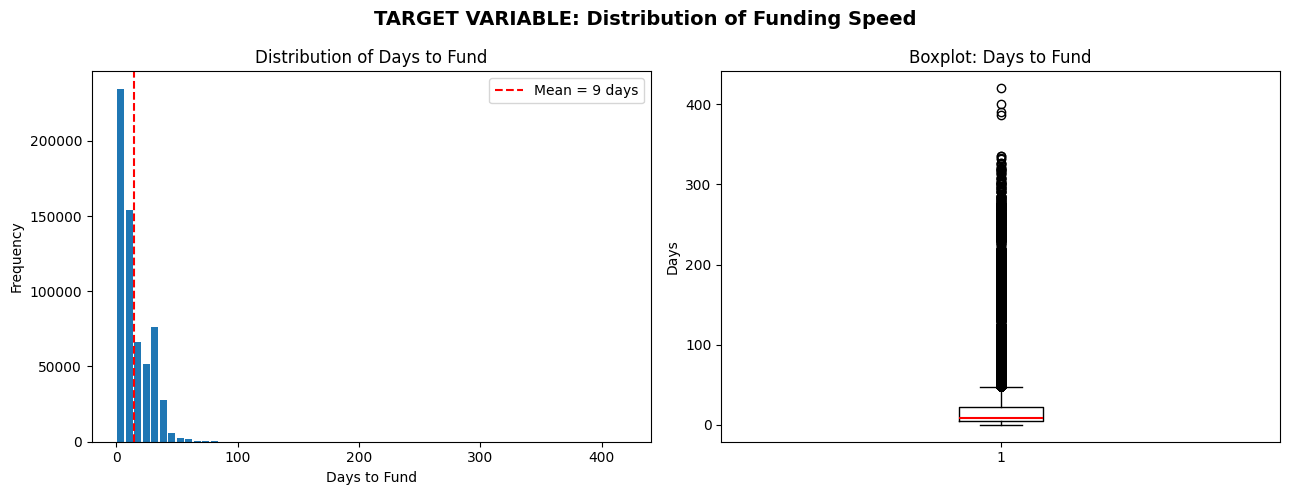

In [11]:
fig, axes = plt.subplots(1,2, figsize=(13,5))

# filter missing value days_to_fund 
funded_df = df[df['days_to_fund'].notna() & (df['days_to_fund'] >= 0)]

axes[0].hist(funded_df['days_to_fund'], bins=60, rwidth=0.8)
axes[0].set_title('Distribution of Days to Fund')
axes[0].set_xlabel('Days to Fund')
axes[0].set_ylabel('Frequency')
axes[0].axvline(funded_df['days_to_fund'].mean(), color='red', linestyle='--',
               label=f'Mean = {funded_df['days_to_fund'].median():.0f} days')
axes[0].legend()

axes[1].boxplot(funded_df['days_to_fund'],medianprops=dict(color="red", linewidth=1.5))
axes[1].set_title("Boxplot: Days to Fund")
axes[1].set_ylabel("Days")

plt.suptitle("TARGET VARIABLE: Distribution of Funding Speed", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
puki = df[df['days_to_fund'] >= 300]
print(puki[['id','posted_time','funded_time','days_to_fund']].head().to_string())

             id               posted_time               funded_time  days_to_fund
24185   1080590 2014-02-26 07:14:14+00:00 2015-01-27 18:28:00+00:00         335.0
42344   1080950 2014-04-08 14:15:38+00:00 2015-06-03 04:01:08+00:00         420.0
106126  1082718 2014-08-21 14:31:39+00:00 2015-07-21 12:29:41+00:00         333.0
106233  1082720 2014-08-21 14:42:45+00:00 2015-07-24 09:10:36+00:00         336.0
106295  1082717 2014-08-21 14:09:28+00:00 2015-07-19 16:15:45+00:00         332.0


### Funding Speed Segmentation 

- nah disini kita atur threshold fast itu di `0 - 0.33` karena kita ingin membuat 3 rule based yaitu `Fast` , `Medium` dan `Slow`

Threshold Fast(0.33)   <= 6 Hari
Threshold Medius(0.66) <= 6 hingga 15 Hari
Threshold Slow         > 15


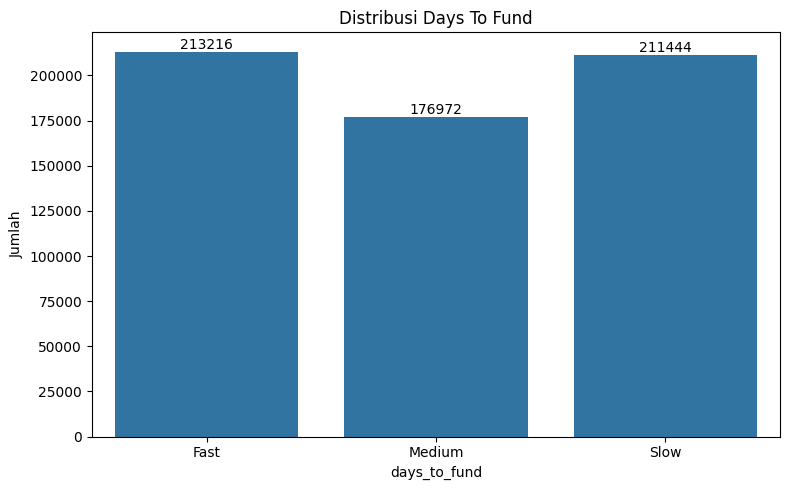

In [42]:
funded_df = df.copy()
# fast 
p33 = funded_df['days_to_fund'].quantile(0.33)
# Medium 
p66 = funded_df['days_to_fund'].quantile(0.66)

# membagi data tersebut menjadi 3 kategori 
funded_df['days_to_fund'] = pd.cut(funded_df['days_to_fund'],
                                  bins=[0, p33, p66, funded_df['days_to_fund'].max()],
                                  labels=['Fast', 'Medium', 'Slow'])

print(f'Threshold Fast(0.33)   <= {p33:.0f} Hari')
print(f'Threshold Medius(0.66) <= {p33:.0f} hingga {p66:.0f} Hari')
print(f'Threshold Slow         > {p66:.0f}')

# Visualisasi 
fig, axes = plt.subplots(figsize=(8,5))
ax = sns.countplot(data=funded_df, x='days_to_fund')
for i in ax.containers:
    ax.bar_label(i)
ax.set_title('Distribusi Days To Fund')
ax.set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

In [26]:
funded_df["days_to_fund"].isna().sum()

np.int64(69573)